## Exploring

In [2]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
pd.set_option('display.max_columns', None)

In [3]:
# Load in data frames
student_df = pd.read_csv(r"Clean Datasets\student_analysis_df.csv")
staff_df = pd.read_csv(r"Clean Datasets\staff_analysis_df.csv")


In [4]:
student_count_yoy = student_df[['Year', 'All Students Count']].groupby('Year').sum().reset_index()

In [5]:
# Add features to Student count YoY dataframe
student_count_yoy['YoY % Change'] = student_count_yoy['All Students Count'].pct_change() * 100
student_count_yoy['YoY Difference'] = student_count_yoy['All Students Count'].diff()

pre_covid_baseline = student_count_yoy.loc[student_count_yoy['Year']==2017, 'All Students Count'].item()
student_count_yoy['Covid Recovery'] = student_count_yoy['All Students Count'] - pre_covid_baseline


student_count_yoy = student_count_yoy[student_count_yoy["Year"]>=2017]

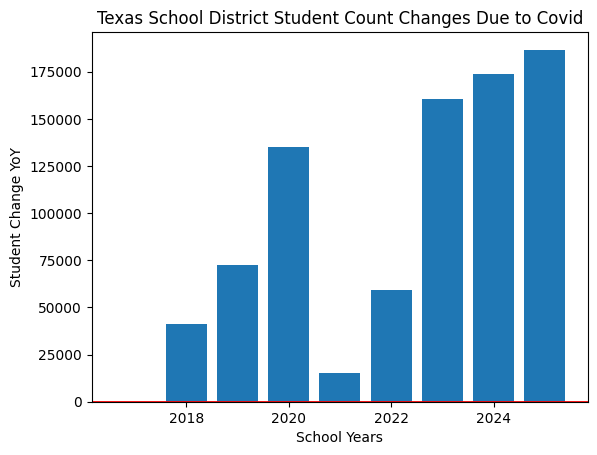

In [6]:
# Bar chart that visualizing covid change

plt.bar(student_count_yoy['Year'],  student_count_yoy['Covid Recovery'])
plt.axhline(y=0, color='Red', linestyle='-', linewidth=2)

# Add labels and a legend
plt.xlabel('School Years')
plt.ylabel('Student Change YoY')
plt.title('Texas School District Student Count Changes Due to Covid')


plt.show()

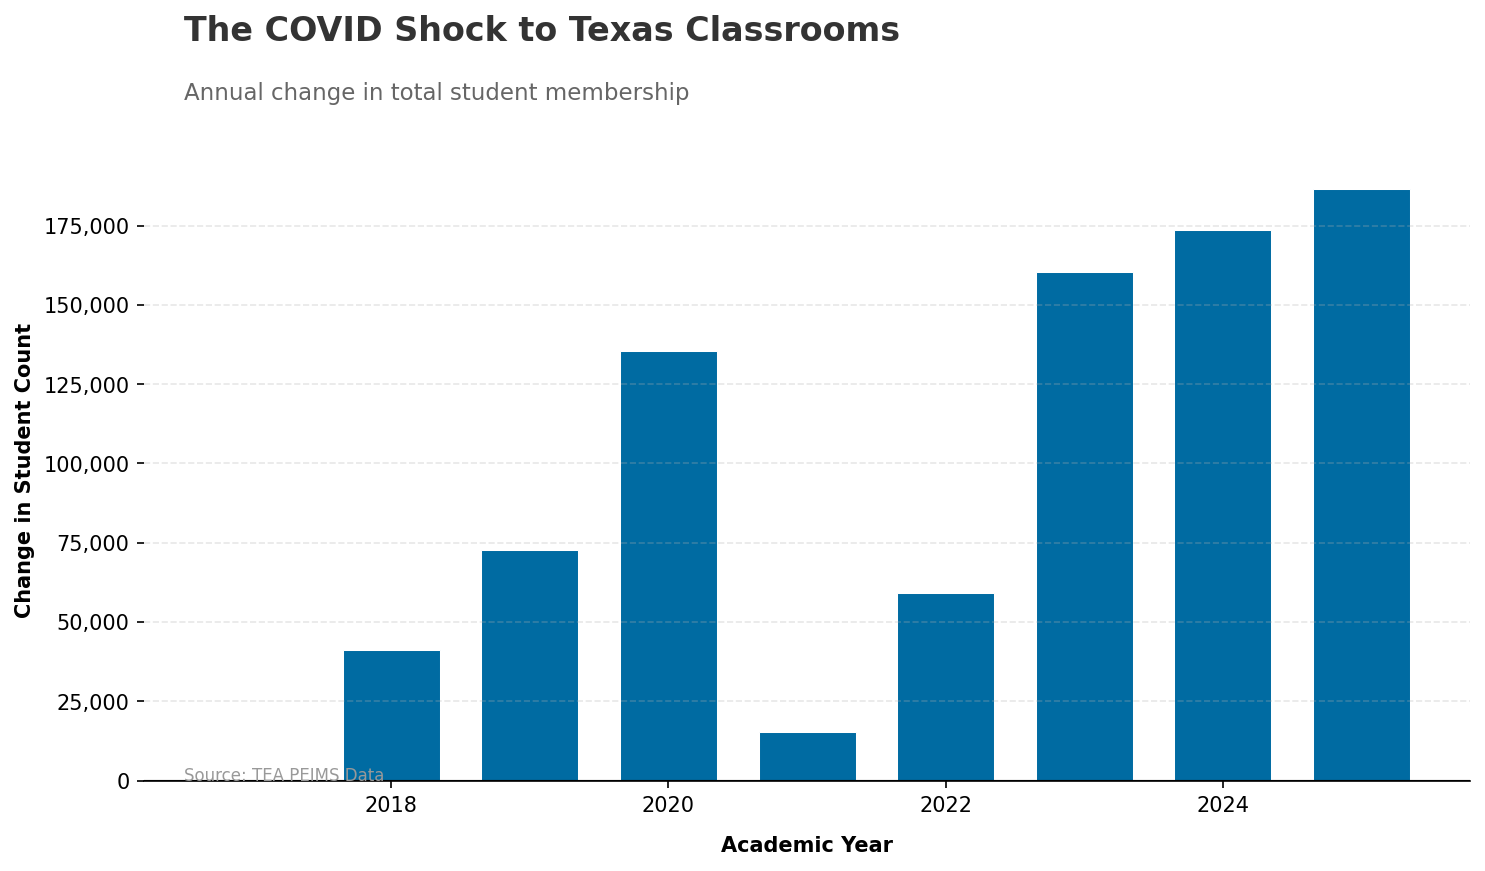

In [7]:
# Create visually appearling style chart

# Set the professional figure size and DPI
plt.figure(figsize=(10, 6), dpi=150)

# 1. Create the bars with conditional coloring (Red for the drop, Blue for recovery)
# Using your specific column names
colors = ['#e3120b' if x < 0 else '#006ba2' for x in student_count_yoy['Covid Recovery']]

plt.bar(student_count_yoy['Year'], student_count_yoy['Covid Recovery'], 
        color=colors, width=0.7, edgecolor='white', linewidth=0.5)

# 2. The Baseline (Your red line, made slightly cleaner)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5)

# 3. Formatting the style axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}')) # Add commas to numbers
ax.yaxis.grid(True, linestyle='--', alpha=0.3) # Subtle horizontal grid only

# 4. Title & Labeling
# Use 'plt.text' for the main title to align it to the far left (standard professional style)
plt.text(x=student_count_yoy['Year'].min()-0.5, 
         y=student_count_yoy['Covid Recovery'].max() * 1.25, 
         s='The COVID Shock to Texas Classrooms', 
         fontsize=16, fontweight='bold', color='#333333')

plt.text(x=student_count_yoy['Year'].min()-0.5, 
         y=student_count_yoy['Covid Recovery'].max() * 1.15, 
         s='Annual change in total student membership', 
         fontsize=11, color='#666666')

plt.xlabel('Academic Year', fontsize=10, fontweight='bold', labelpad=10)
plt.ylabel('Change in Student Count', fontsize=10, fontweight='bold')

# 5. Add a source tag at the bottom
plt.text(x=student_count_yoy['Year'].min()-0.5, 
         y=student_count_yoy['Covid Recovery'].min() * 1.3, 
         s='Source: TEA PEIMS Data', fontsize=8, color='#999999')

plt.tight_layout()
plt.show()

In [8]:
def remove_row_groups(df, column_name, ):
    """
    Creates splits the DataFrame into groups based on the unique values in the 'Group' column.
    the removes the rows you specify if you want to delete
    """
    # Filter groups: keep only groups where ALL values in 'Value_Col' are >= threshold
    # Keeps only groups where all values in column_name, 
    df = df.groupby('Group').filter(lambda x: (x[column_name] >= 30).all())
    return df

In [9]:
student_df.columns

Index(['YearDistrict ID', 'Year', 'DISTRICT', 'EE Count', 'PK Count',
       'KG Count', '01 Count', '02 Count', '03 Count', '04 Count', '05 Count',
       '06 Count', '07 Count', '08 Count', '09 Count', '10 Count', '11 Count',
       '12 Count', 'All Students Count', 'Special Ed Count',
       'Bilingual/ESL Count', 'Career & Technical Education Count',
       'Gifted & Talented Count', 'EB/EL Count', 'Econ Disadv Count',
       'Non-Educationally Disadv Count', 'At Risk Count',
       'American Indian Count', 'Asian Count', 'Pacific Islander Count',
       'Two or More Races Count', 'African American Count', 'Hispanic Count',
       'White Count', 'Male Count', 'Female Count', 'Dyslexia Count',
       'Section 504 Count', 'Title I Count', 'Homeless Count',
       'Immigrant Count', 'Migrant Count', 'Military-Connected Count',
       'PK Count Ages 3 and Under Count', 'PK Count Ages 4 and Over Count',
       'Foster Care Count', 'Career & Technical (9-12) Education Count',
       '202

In [10]:
#student_df = student_df[student_df['All Students Count']]

x = student_df.shape
student_df.groupby('DISTRICT').filter(lambda x: (x[''] >= 30).all())



KeyError: ''

In [ ]:
# filter df for 

#student_df['All Students Count']

Index(['Year', 'DISTRICT', 'EE Count', 'PK Count', 'KG Count', '01 Count',
       '02 Count', '03 Count', '04 Count', '05 Count', '06 Count', '07 Count',
       '08 Count', '09 Count', '10 Count', '11 Count', '12 Count',
       'All Students Count', 'Special Ed Count', 'Bilingual/ESL Count',
       'Career & Technical Education Count', 'Gifted & Talented Count',
       'EB/EL Count', 'Econ Disadv Count', 'Non-Educationally Disadv Count',
       'At Risk Count', 'American Indian Count', 'Asian Count',
       'Pacific Islander Count', 'Two or More Races Count',
       'African American Count', 'Hispanic Count', 'White Count', 'Male Count',
       'Female Count', 'Dyslexia Count', 'Section 504 Count', 'Title I Count',
       'Homeless Count', 'Immigrant Count', 'Migrant Count',
       'Military-Connected Count', 'PK Count Ages 3 and Under Count',
       'PK Count Ages 4 and Over Count', 'Foster Care Count',
       'Career & Technical (9-12) Education Count',
       '2022-23 Attrition All 